<a href="https://colab.research.google.com/github/jishnujs1990/Study/blob/master/ML_Assignment_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective: The main objective of this project is to design and implement a robust data
preprocessing system that addresses common challenges such as missing values, outliers,
inconsistent formatting, and noise.

By performing effective data preprocessing, the project aims to enhance the quality, reliability,
and usefulness of the data for machine learning.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [45]:
df = pd.read_csv('Employee.csv')
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


Data Exploration: (Score : 2)
● Explore the data, list down the unique values in each feature and find its length.
● Perform the statistical analysis and renaming of the columns.

In [46]:
for column in df.columns:
    unique_vals = df[column].unique()
    print(f"\nFeature: '{column}'")
    print(f"Number of Unique Values: {len(unique_vals)}")
    print(f"Unique Values: {unique_vals}")


Feature: 'Company'
Number of Unique Values: 7
Unique Values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']

Feature: 'Age'
Number of Unique Values: 30
Unique Values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]

Feature: 'Salary'
Number of Unique Values: 41
Unique Values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]

Feature: 'Place'
Number of Unique Values: 12
Unique Values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']

Feature: 'Country'
Number of Unique Values: 1
Unique Values: ['India']

Feature: 'Gender'
Number of Unique Values: 2
Unique Values: [0 1]


In [47]:
print(df.describe(include=[np.number]))

              Age       Salary      Gender
count  130.000000   124.000000  148.000000
mean    30.484615  5312.467742    0.222973
std     11.096640  2573.764683    0.417654
min      0.000000  1089.000000    0.000000
25%     22.000000  3030.000000    0.000000
50%     32.500000  5000.000000    0.000000
75%     37.750000  8000.000000    0.000000
max     54.000000  9876.000000    1.000000


In [48]:
print(df.describe(include=[object]))

       Company   Place Country
count      140     134     148
unique       6      11       1
top        TCS  Mumbai   India
freq        53      37     148


In [49]:
df.rename(columns={
    'Age': 'age',
    'Salary': 'salary',
    'Place': 'place',
    'Company': 'company',
    'Country':'country',
    'Gender': 'gender'
}, inplace=True, errors='ignore')

print("\nColumns after renaming standardisation:")
print(df.columns.tolist())


Columns after renaming standardisation:
['company', 'age', 'salary', 'place', 'country', 'gender']


2. Data Cleaning: (Score : 2)
● Find the missing and inappropriate values, treat them appropriately.
● Remove all duplicate rows.
● Find the outliers.
● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

In [50]:
# ● Replace the value 0 in age as NaN
if 'age' in df.columns:
    df['age'] = df['age'].replace(0, np.nan)
    print("Replaced 0 values in 'age' with NaN.")

Replaced 0 values in 'age' with NaN.


In [51]:
# ● Find missing values count before treatment
print("\nMissing values per column before treatment:")
print(df.isnull().sum())


Missing values per column before treatment:
company     8
age        24
salary     24
place      14
country     0
gender      0
dtype: int64


In [52]:
# ● Treat null values in all columns using mean/median/mode
# Imputing Numerical Columns
if 'age' in df.columns:
    # Median is robust to outliers
    df['age'] = df['age'].fillna(df['age'].median())
if 'salary' in df.columns:
    # Mean or Median depending on distribution
    df['salary'] = df['salary'].fillna(df['salary'].mean())

In [53]:
# ● Find missing values count before treatment
print("\nMissing values per column before treatment:")
print(df.isnull().sum())


Missing values per column before treatment:
company     8
age         0
salary      0
place      14
country     0
gender      0
dtype: int64


In [54]:
for col in df.select_dtypes(include=[object]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values per column after treatment:")
print(df.isnull().sum())


Missing values per column after treatment:
company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64


In [55]:
# ● Remove all duplicate rows
duplicate_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"\nRemoved {duplicate_count} duplicate row(s).")


Removed 4 duplicate row(s).


In [56]:
# ● Find Outliers using the Interquartile Range (IQR) method
print("\nDetecting Outliers via IQR Method:")
numerical_cols = df.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  - '{col}' has {len(outliers)} outliers outside range ({lower_bound:.2f} to {upper_bound:.2f})")


Detecting Outliers via IQR Method:
  - 'age' has 0 outliers outside range (5.38 to 54.38)
  - 'salary' has 0 outliers outside range (-3013.50 to 13142.50)
  - 'gender' has 32 outliers outside range (0.00 to 0.00)


3. Data Analysis: (Score : 2)
● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
Count the number of people from each place and represent it visually

In [57]:
# ● Filter data with age > 40 and salary < 5000
filtered_df = df[(df['age'] > 40) & (df['salary'] < 5000)]
print(f"Number of records matching (Age > 40 and Salary < 5000): {len(filtered_df)}")
print(filtered_df)

Number of records matching (Age > 40 and Salary < 5000): 15
     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


Text(0, 0.5, 'Salary')

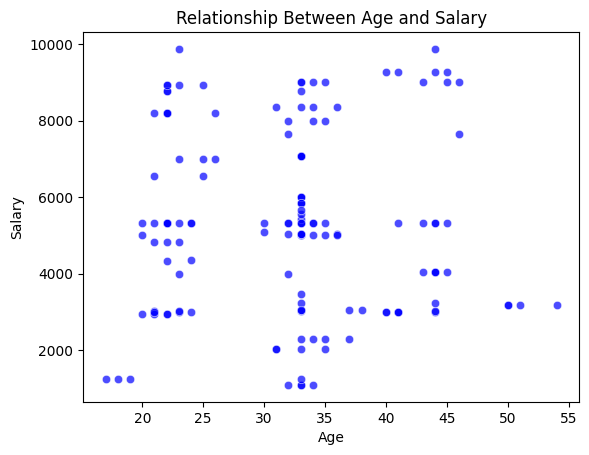

In [58]:
# ● Plot 1: Chart with age and salary (Scatter plot to check relationship)
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x='age', y='salary', color='blue', alpha=0.7)
plt.title('Relationship Between Age and Salary')
plt.xlabel('Age')
plt.ylabel('Salary')

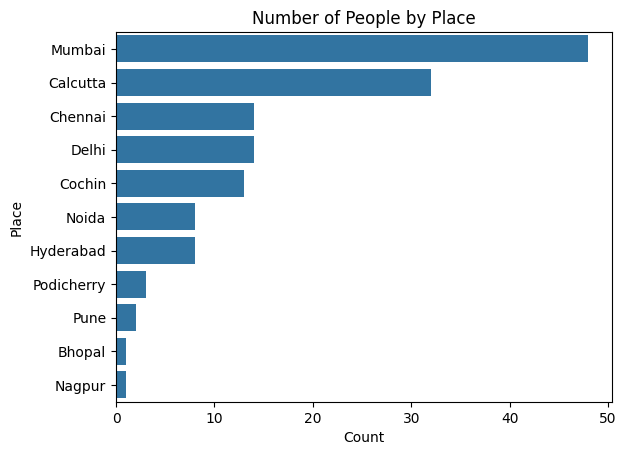

In [59]:
# ● Plot 2: Count the number of people from each place and represent visually
if 'place' in df.columns:
    sns.countplot(
        data=df,
        y='place',
        order=df['place'].value_counts().index
    )
    plt.title('Number of People by Place')
    plt.xlabel('Count')
    plt.ylabel('Place')

4. Data Encoding: (Score : 2)
● Convert categorical variables into numerical representations using techniques
such as one-hot encoding, label encoding, making them suitable for analysis by
machine learning algorithms.

In [60]:
#copy of dataframe
df_encoded = df.copy()

In [61]:
#categorical_cols
categorical_cols = df_encoded.select_dtypes(include=[object]).columns
print(f"Categorical variables to encode: {list(categorical_cols)}")

Categorical variables to encode: ['company', 'place', 'country']


In [62]:
#label encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
if 'company' in df_encoded.columns:
    le = LabelEncoder()
    df_encoded['company_encoded'] = le.fit_transform(df_encoded['company'])
    print("Applied Label Encoding to 'company'.")

Applied Label Encoding to 'company'.


In [63]:
#onehot encoding
df_encoded = pd.get_dummies(df_encoded, columns=['place'], drop_first=True, dtype=int)
print("Applied One-Hot Encoding to 'place'.")

Applied One-Hot Encoding to 'place'.


In [64]:
df_encoded = pd.get_dummies(df_encoded, columns=['country'], drop_first=True, dtype=int)
print("Applied One-Hot Encoding to 'place'.")

Applied One-Hot Encoding to 'place'.


5. Feature Scaling: (Score : 2)
● After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

In [65]:
features_to_scale = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
print(f"Features selected for scaling: {features_to_scale}")

Features selected for scaling: ['age', 'salary', 'gender', 'company_encoded', 'place_Calcutta', 'place_Chennai', 'place_Cochin', 'place_Delhi', 'place_Hyderabad', 'place_Mumbai', 'place_Nagpur', 'place_Noida', 'place_Podicherry', 'place_Pune']


In [71]:
# ● Standard Scaler (Transforms data to mean=0, std=1)
scaler_standard = StandardScaler()
df_standard_scaled = df_encoded.copy()
df_standard_scaled[features_to_scale] = scaler_standard.fit_transform(df_encoded[features_to_scale])

print("\nFirst 3 Rows after StandardScaler Transformations")
print(df_standard_scaled[features_to_scale].head(3))


First 3 Rows after StandardScaler Transformations
        age    salary    gender  company_encoded  place_Calcutta  \
0 -1.484676  0.010324 -0.534522         0.991489       -0.534522   
1 -0.267174  0.010324 -0.534522        -0.239325       -0.534522   
2  0.341577 -1.266072 -0.534522         0.991489        1.870829   

   place_Chennai  place_Cochin  place_Delhi  place_Hyderabad  place_Mumbai  \
0       3.047247     -0.315018    -0.328165        -0.242536     -0.707107   
1      -0.328165     -0.315018    -0.328165        -0.242536      1.414214   
2      -0.328165     -0.315018    -0.328165        -0.242536     -0.707107   

   place_Nagpur  place_Noida  place_Podicherry  place_Pune  
0     -0.083624    -0.242536         -0.145865   -0.118678  
1     -0.083624    -0.242536         -0.145865   -0.118678  
2     -0.083624    -0.242536         -0.145865   -0.118678  


In [70]:
# ● MinMaxScaler (Transforms data bounded strictly between 0 and 1)
scaler_minmax = MinMaxScaler()
df_minmax_scaled = df_encoded.copy()
df_minmax_scaled[features_to_scale] = scaler_minmax.fit_transform(df_encoded[features_to_scale])

print("\n First 3 Rows after MinMaxScaler Transformations")
print(df_minmax_scaled[features_to_scale].head(3))


 First 3 Rows after MinMaxScaler Transformations
        age    salary  gender  company_encoded  place_Calcutta  place_Chennai  \
0  0.081081  0.480650     0.0              0.8             0.0            1.0   
1  0.351351  0.480650     0.0              0.4             0.0            0.0   
2  0.486486  0.137817     0.0              0.8             1.0            0.0   

   place_Cochin  place_Delhi  place_Hyderabad  place_Mumbai  place_Nagpur  \
0           0.0          0.0              0.0           0.0           0.0   
1           0.0          0.0              0.0           1.0           0.0   
2           0.0          0.0              0.0           0.0           0.0   

   place_Noida  place_Podicherry  place_Pune  
0          0.0               0.0         0.0  
1          0.0               0.0         0.0  
2          0.0               0.0         0.0  
